# Linear Discriminant Analysis (LDA)

In [2]:
from dependencies import *
from data_pipeline import load_pipeline, FEATURES

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, FEATURES, scaler = load_pipeline()


Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (698, 17)
Class weights: {np.int64(0): np.float64(0.778149386845039), np.int64(1): np.float64(1.1633333333333333), np.int64(2): np.float64(1.169179229480737)}

Outputs ready for modeling:
  X_train_bal       → (698, 17) (balanced, scaled)
  y_train_bal       → 698 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = [
    {
        "solver": ["svd"],
        # svd doesn't support shrinkage — no shrinkage param here
    },
    {
        "solver": ["lsqr", "eigen"],
        "shrinkage": ["auto", 0.0, 0.1, 0.25, 0.5, 0.75, 1.0],
    },
]

grid_lda = GridSearchCV(
    LinearDiscriminantAnalysis(),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_lda.fit(X_train_bal, y_train_bal)

lda = grid_lda.best_estimator_
print(f"Best params: {grid_lda.best_params_}")
print(f"Best CV F1 Macro: {grid_lda.best_score_:.4f}")

y_pred_lda = lda.predict(X_test_scaled)
y_prob_lda = lda.predict_proba(X_test_scaled)

# Projection model for diagnostic plots (lsqr doesn't support .transform or .scalings_)
lda_proj = LinearDiscriminantAnalysis(
    solver="eigen",
    shrinkage=lda.shrinkage if hasattr(lda, 'shrinkage') and lda.shrinkage is not None else "auto",
)
lda_proj.fit(X_train_bal, y_train_bal)
X_train_lda = lda_proj.transform(X_train_bal)
X_test_lda  = lda_proj.transform(X_test_scaled)

class_labels = ["Non-Habitable (0)", "Mesoplanet (1)", "Psychroplanet (2)"]
colors = ["#2196F3", "#FF9800", "#4CAF50"]
classes = np.array([0.0, 1.0, 2.0])

print("LDA training complete.")
print(f"Number of discriminant components: {X_train_lda.shape[1]}")
print(f"Test predictions shape: {y_pred_lda.shape}")

Best params: {'shrinkage': 0.5, 'solver': 'lsqr'}
Best CV F1 Macro: 0.7602
LDA training complete.
Number of discriminant components: 2
Test predictions shape: (1114,)


## Modeling
### DIAGNOSTIC PLOT 1: LDA Discriminant Space — Decision Boundaries
LDA projects data onto axes that maximise class separation.  
With 3 classes we get exactly 2 discriminant axes (LD1, LD2).  
This IS the space where LDA makes its decisions and every prediction is a nearest-centroid lookup here.


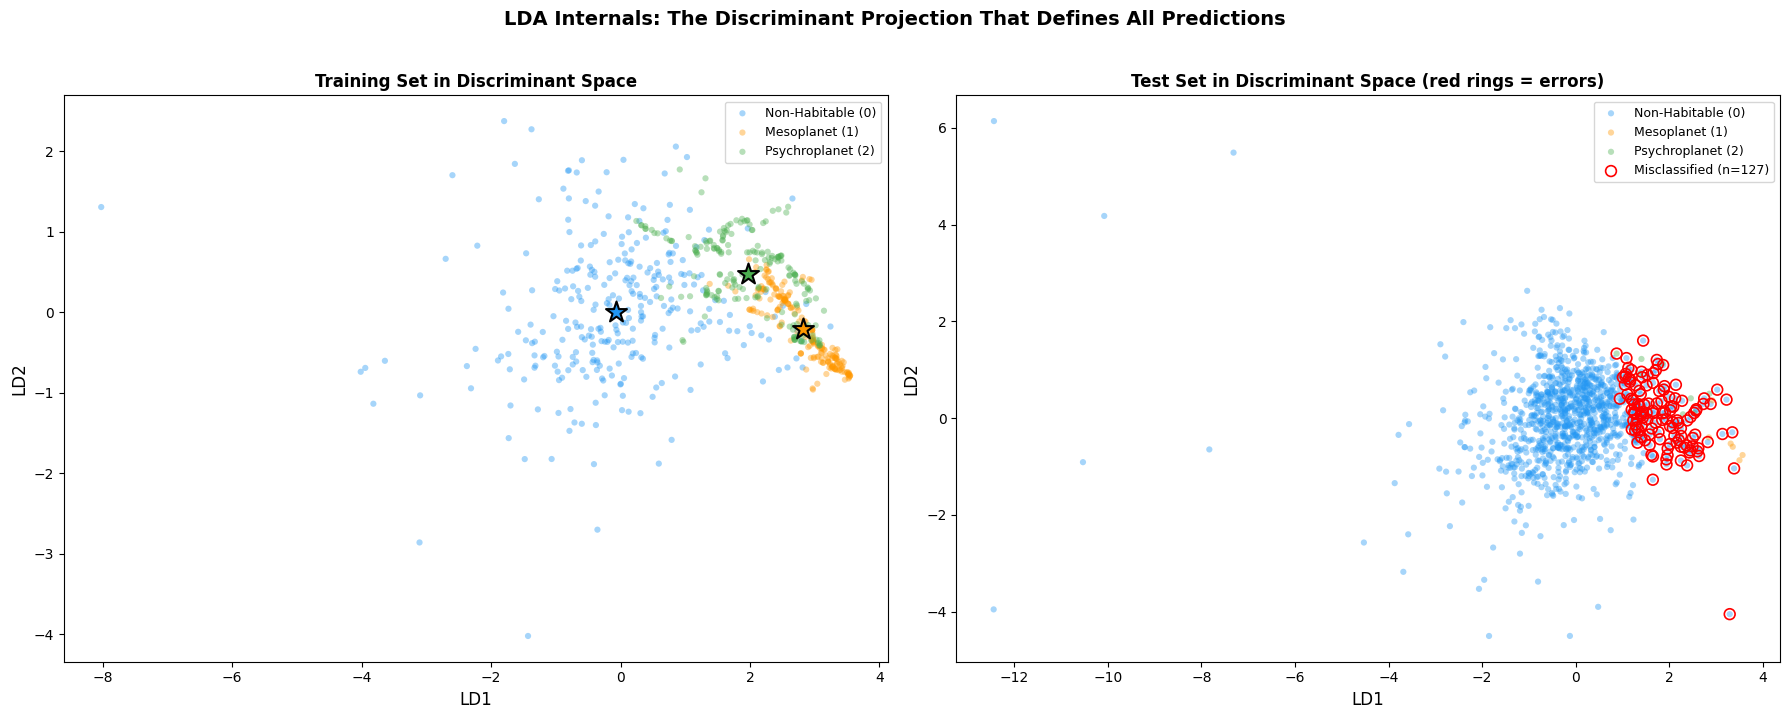

↑ LDA projects all 17 features onto 2 axes (LD1, LD2) that maximise class separation.
  Stars = class centroids. Every prediction = 'which centroid is closest?'
  Red rings on the right = test samples that were assigned to the wrong centroid.



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left panel: Training data (balanced) ---
ax = axes[0]
# --- Left panel ---
for i, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
    mask = (y_train_bal == cls).values if hasattr(y_train_bal, 'values') else (y_train_bal == cls)
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               c=color, label=label, alpha=0.4, s=20, edgecolors="none")

centroids_lda = np.array([X_train_lda[(y_train_bal == c).values if hasattr(y_train_bal, 'values') else (y_train_bal == c)].mean(axis=0) for c in classes])

# Plot class centroids in discriminant space
centroids_lda = np.array([X_train_lda[y_train_bal == c].mean(axis=0) for c in classes])
for i, (cx, cy) in enumerate(centroids_lda):
    ax.scatter(cx, cy, c=colors[i], s=250, marker="*", edgecolors="black",
               linewidth=1.5, zorder=5)

ax.set_xlabel("LD1", fontsize=12)
ax.set_ylabel("LD2", fontsize=12)
ax.set_title("Training Set in Discriminant Space", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="best")

# --- Right panel: Test data (original distribution) ---
ax = axes[1]
for i, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
    mask = (y_test == cls).values if hasattr(y_test, 'values') else (y_test == cls)
    ax.scatter(X_test_lda[mask, 0], X_test_lda[mask, 1],
               c=color, label=label, alpha=0.4, s=20, edgecolors="none")

misclassified = (y_pred_lda != y_test).values if hasattr(y_test, 'values') else (y_pred_lda != y_test)

# Show misclassified test points
misclassified = y_pred_lda != y_test
ax.scatter(X_test_lda[misclassified, 0], X_test_lda[misclassified, 1],
           facecolors="none", edgecolors="red", s=60, linewidths=1.2,
           label=f"Misclassified (n={misclassified.sum()})", zorder=4)

ax.set_xlabel("LD1", fontsize=12)
ax.set_ylabel("LD2", fontsize=12)
ax.set_title("Test Set in Discriminant Space (red rings = errors)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="best")

fig.suptitle("LDA Internals: The Discriminant Projection That Defines All Predictions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_discriminant_space")
plt.show()

print("↑ LDA projects all 17 features onto 2 axes (LD1, LD2) that maximise class separation.")
print("  Stars = class centroids. Every prediction = 'which centroid is closest?'")
print("  Red rings on the right = test samples that were assigned to the wrong centroid.\n")

### DIAGNOSTIC PLOT 2: Feature Contributions to Discriminant Axes
LDA's weight matrix (scalings_) tells you exactly how much each original feature contributes to LD1 and LD2This is analogous to PCA loadings but optimised for class separation rather than variance.


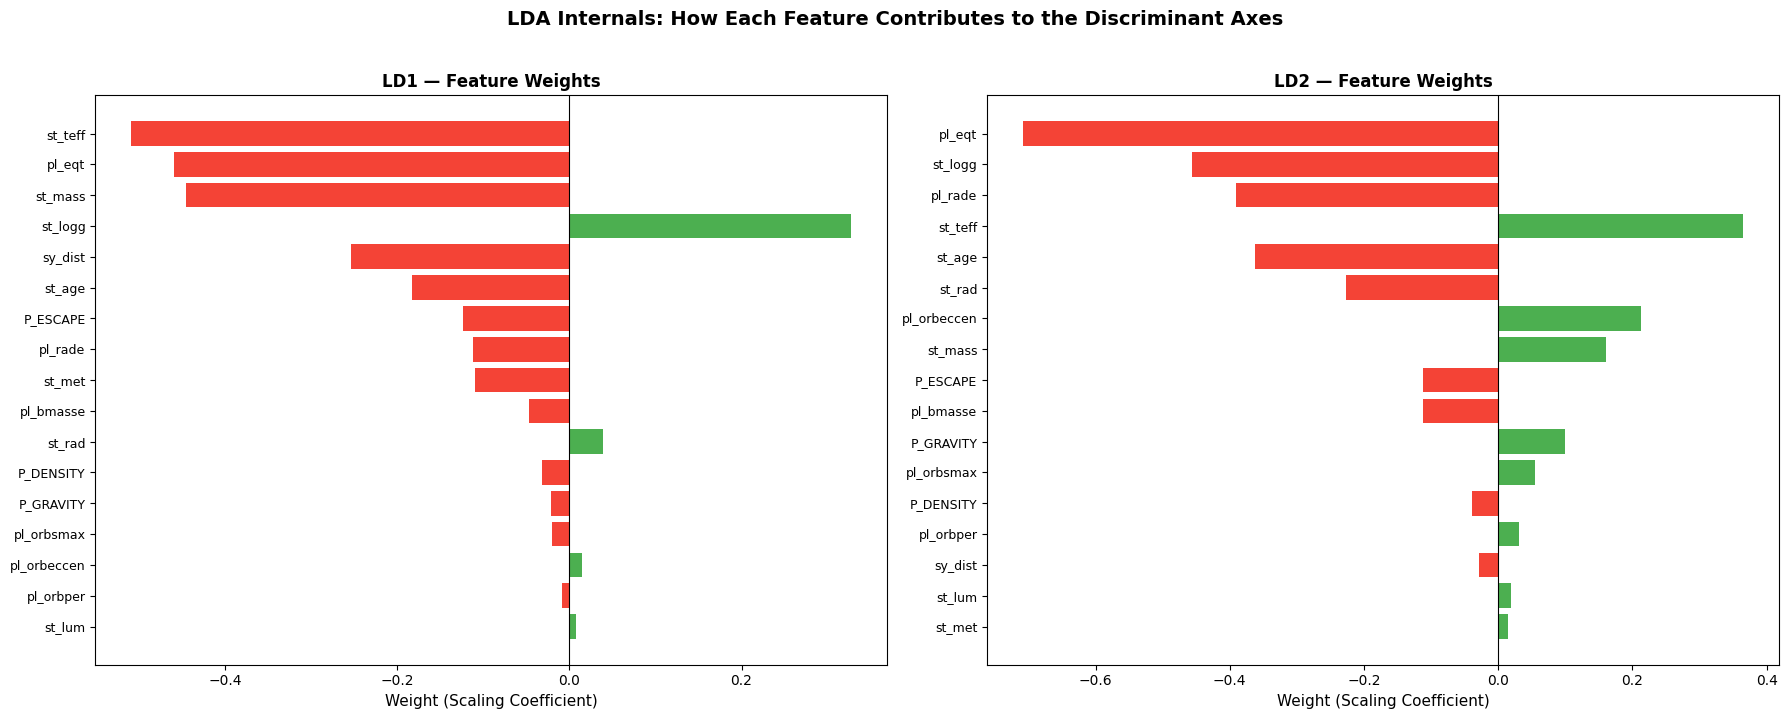

↑ These are the coefficients LDA uses to build LD1 and LD2 from the 17 raw features.
  Green = positive contribution, Red = negative. Longer bars = more influential features.
  Unlike tree-based 'importance', these are exact linear weights — fully interpretable.



In [7]:
scalings = lda_proj.scalings_  # ← was lda.scalings_
feature_names = FEATURES

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for comp_idx, ax in enumerate(axes):
    weights = scalings[:, comp_idx]
    sorted_idx = np.argsort(np.abs(weights))[::-1]

    sorted_weights = weights[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]
    bar_colors = ["#4CAF50" if w > 0 else "#F44336" for w in sorted_weights]

    ax.barh(range(len(sorted_names)), sorted_weights, color=bar_colors, edgecolor="none")
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Weight (Scaling Coefficient)", fontsize=11)
    ax.set_title(f"LD{comp_idx + 1} — Feature Weights", fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", lw=0.8)

fig.suptitle("LDA Internals: How Each Feature Contributes to the Discriminant Axes",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_feature_weights")
plt.show()

print("↑ These are the coefficients LDA uses to build LD1 and LD2 from the 17 raw features.")
print("  Green = positive contribution, Red = negative. Longer bars = more influential features.")
print("  Unlike tree-based 'importance', these are exact linear weights — fully interpretable.\n")

### DIAGNOSTIC PLOT 3: Class-Conditional Distributions Along Each LD Axis
Shows how well-separated the classes are along each discriminant axis individually.  
This reveals which axis does the heavy lifting.


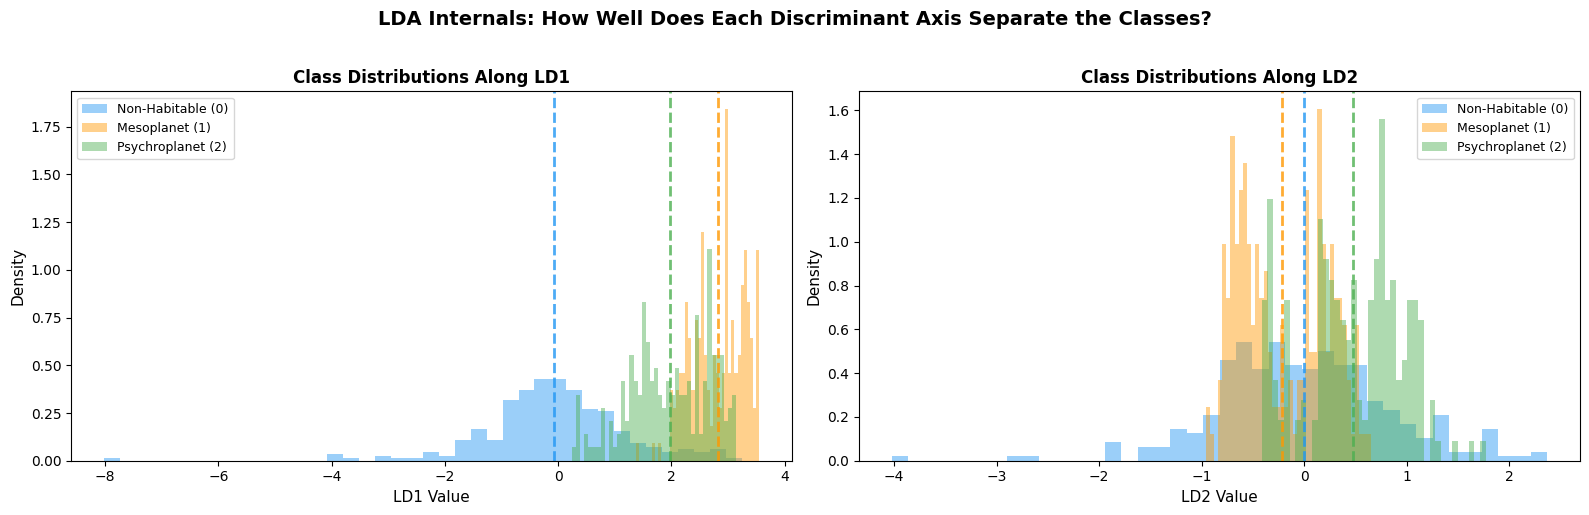

↑ Dashed lines = class means along each axis.
  LD1 typically handles the biggest class split; LD2 captures remaining separation.
  Overlapping histograms → confusion between those classes on that axis.



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for comp_idx, ax in enumerate(axes):
    for i, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
        if hasattr(y_train_bal, 'values'):
            mask = (y_train_bal.values == cls)
        else:
            mask = (y_train_bal == cls)
        values = X_train_lda[mask, comp_idx]
        ax.hist(values, bins=40, alpha=0.45, color=color, label=label, density=True)
        ax.axvline(values.mean(), color=color, ls="--", lw=2, alpha=0.8)

    ax.set_xlabel(f"LD{comp_idx + 1} Value", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"Class Distributions Along LD{comp_idx + 1}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("LDA Internals: How Well Does Each Discriminant Axis Separate the Classes?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_axis_distributions")
plt.show()

print("↑ Dashed lines = class means along each axis.")
print("  LD1 typically handles the biggest class split; LD2 captures remaining separation.")
print("  Overlapping histograms → confusion between those classes on that axis.\n")

## Metrics
### Classification Report + F1 Scores

LDA — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9990    0.8864    0.9393      1100
   Mesoplanet     0.1333    1.0000    0.2353         6
Psychroplanet     0.0645    0.7500    0.1188         8

     accuracy                         0.8860      1114
    macro avg     0.3989    0.8788    0.4311      1114
 weighted avg     0.9876    0.8860    0.9296      1114

F1 Macro:    0.4311
F1 Weighted: 0.9296

5-Fold CV F1 Macro: 0.7445 ± 0.0339


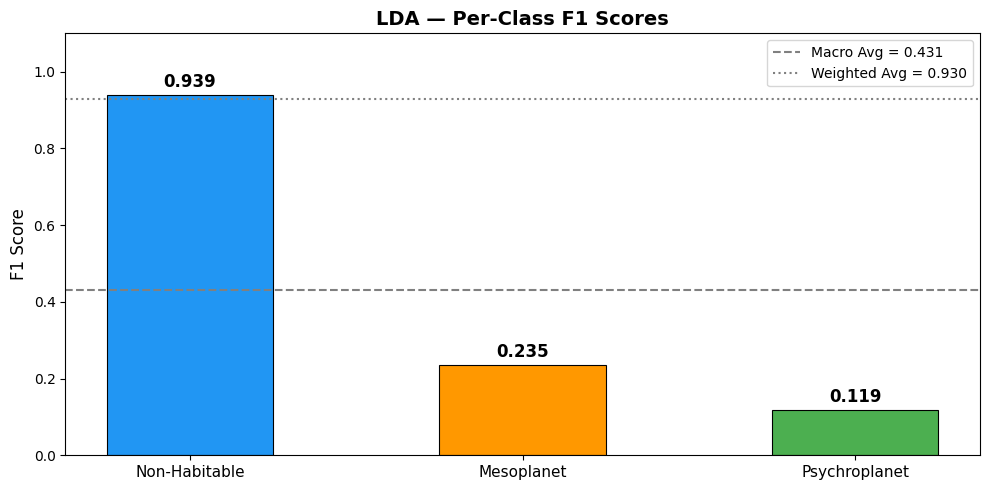

In [9]:
# Print text report
print("=" * 60)
print("LDA — Classification Report")
print("=" * 60)
class_names = ["Non-Habitable", "Mesoplanet", "Psychroplanet"]
print(classification_report(y_test, y_pred_lda, target_names=class_names, digits=4, zero_division=0))

f1_macro_lda   = f1_score(y_test, y_pred_lda, average="macro")
f1_weighted_lda = f1_score(y_test, y_pred_lda, average="weighted")
print(f"F1 Macro:    {f1_macro_lda:.4f}")
print(f"F1 Weighted: {f1_weighted_lda:.4f}")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lda = cross_val_score(lda, X_train_bal, y_train_bal, cv=cv, scoring="f1_macro")
print(f"\n5-Fold CV F1 Macro: {cv_scores_lda.mean():.4f} ± {cv_scores_lda.std():.4f}")

# ── Per-class F1 bar chart ──
f1_per_class = f1_score(y_test, y_pred_lda, average=None, labels=classes, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(class_names))
bars = ax.bar(x_pos, f1_per_class, color=colors, edgecolor="black", linewidth=0.8, width=0.5)

for bar, score in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(f1_macro_lda, color="gray", ls="--", lw=1.5, label=f"Macro Avg = {f1_macro_lda:.3f}")
ax.axhline(f1_weighted_lda, color="gray", ls=":", lw=1.5, label=f"Weighted Avg = {f1_weighted_lda:.3f}")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("LDA — Per-Class F1 Scores", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("lda_f1_scores")
plt.show()

### Confusion Matrix (Counts + Normalized)

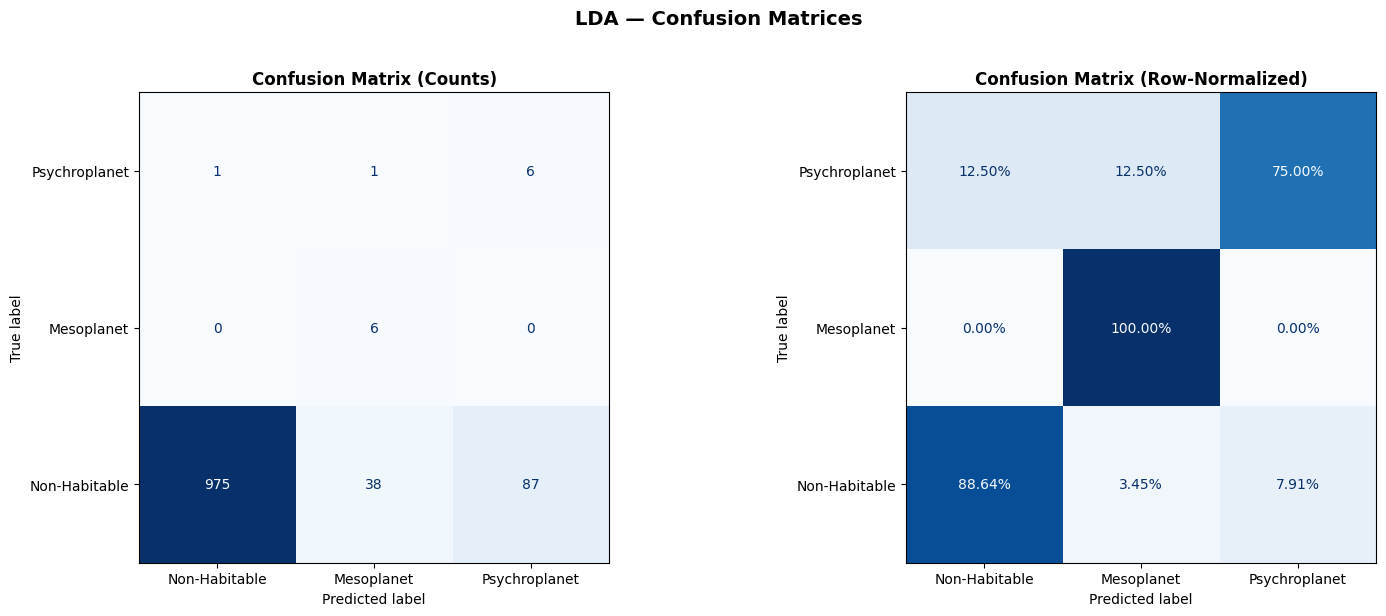

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 38 (3.5% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 87 (7.9% of true Non-Habitable)
  Psychroplanet → predicted Non-Habitable: 1 (12.5% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [11]:
cm_lda = confusion_matrix(y_test, y_pred_lda, labels=classes)
cm_lda_norm = cm_lda.astype(float) / cm_lda.sum(axis=1, keepdims=True)

# Reorder: rows reversed (Psychro, Meso, Non-Hab top-to-bottom),
#          columns original (Non-Hab, Meso, Psychro left-to-right)
row_order = [2, 1, 0]  # Psychroplanet, Mesoplanet, Non-Habitable
col_order = [0, 1, 2]  # Non-Habitable, Mesoplanet, Psychroplanet

cm_lda_reordered = cm_lda[np.ix_(row_order, col_order)]
cm_lda_norm_reordered = cm_lda_norm[np.ix_(row_order, col_order)]

y_labels = [class_names[i] for i in row_order]   # Psychro, Meso, Non-Hab
x_labels = [class_names[i] for i in col_order]    # Non-Hab, Meso, Psychro

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp1 = ConfusionMatrixDisplay(cm_lda_reordered, display_labels=x_labels)
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_yticklabels(y_labels)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=12, fontweight="bold")

# Normalized
disp2 = ConfusionMatrixDisplay(cm_lda_norm_reordered, display_labels=x_labels)
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2%")
axes[1].set_yticklabels(y_labels)
axes[1].set_title("Confusion Matrix (Row-Normalized)", fontsize=12, fontweight="bold")

fig.suptitle("LDA — Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("lda_confusion_matrix")
plt.show()

# Print the main error patterns
print("Key error patterns:")
for i, true_name in enumerate(class_names):
    for j, pred_name in enumerate(class_names):
        if i != j and cm_lda[i, j] > 0:
            print(f"  {true_name} → predicted {pred_name}: {cm_lda[i, j]} "
                  f"({cm_lda_norm[i, j]:.1%} of true {true_name})")


## Interpretation:
LDA achieves perfect recall on Mesoplanets (6/6) and 75% Psychroplanet recall (75%), meaning it finds nearly all habitable worlds. 

However, it generates 125 false positives from the Non-Habitable class (38 as Mesoplanet, 87 as Psychroplanet), which tanks precision for both minority classes to ~13% and ~6% respectively. The model is essentially over-eager: it learned a linear boundary that casts a wide net around habitable regions in discriminant space, catching all true positives but sweeping in many Non-Habitable planets too. 

The F1 macro (0.43) vs weighted (0.92) gap confirms this is a class-imbalance problem — LDA performs well on the dominant class but poorly distinguishes the rare ones. 

Compared to GNB, LDA trades slightly better minority recall for even worse precision, suggesting its linear decision boundary is too coarse for the overlap between Non-Habitable and habitable classes in this feature space.